Following https://www.youtube.com/watch?v=TCH_1BHY58I&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=3

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [26]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words = [word.lower() for word in words]  # Convert to lower case
words[:8]

['olivia', 'emma', 'charlotte', 'amelia', 'sophia', 'isabella', 'ava', 'mia']

In [27]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [110]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [152]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([180237, 3]) torch.Size([180237])
torch.Size([22472, 3]) torch.Size([22472])
torch.Size([22359, 3]) torch.Size([22359])


In [29]:
C = torch.randn((27, 2))

In [ ]:
emb = C[X]
print(emb.shape)

torch.Size([225068, 3, 2])


In [33]:
# now time for the hidden layer
W = torch.randn((6, 100)) # 2 dimensional embeddings for each of 3 input characters for input, 100 neurons
b = torch.randn(100)

In [34]:
emb @ W + b

RuntimeError: mat1 and mat2 shapes cannot be multiplied (675204x2 and 6x100)

In [39]:
# lame way to prepare emb for matrix multiplication with weights
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape

torch.Size([225068, 6])

In [42]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([225068, 6])

In [50]:

emb.view(emb.shape[0], 6)

tensor([[ 0.2821,  0.3432,  0.2821,  0.3432,  0.2821,  0.3432],
        [ 0.2821,  0.3432,  0.2821,  0.3432, -0.4326,  0.0227],
        [ 0.2821,  0.3432, -0.4326,  0.0227, -0.8567, -1.4810],
        ...,
        [ 0.7722,  0.9879, -1.8569,  1.0343, -0.4867, -0.5563],
        [-1.8569,  1.0343, -0.4867, -0.5563,  0.0131,  0.3946],
        [-0.4867, -0.5563,  0.0131,  0.3946, -1.8569,  1.0343]])

In [51]:
a.storage()

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [193]:
# the nice version
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [138]:
# learn the learning rate
lrs = 10**torch.linspace(-3, 0, 1000)
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [194]:
lri = []
lossi = []
stepi = []

In [202]:
for p in parameters:
    p.requires_grad = True
for i in range(50000):
    # build a minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss = -prob[torch.arange(225068), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    #lri.append(lrs[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
print(loss.item())

2.3678157329559326


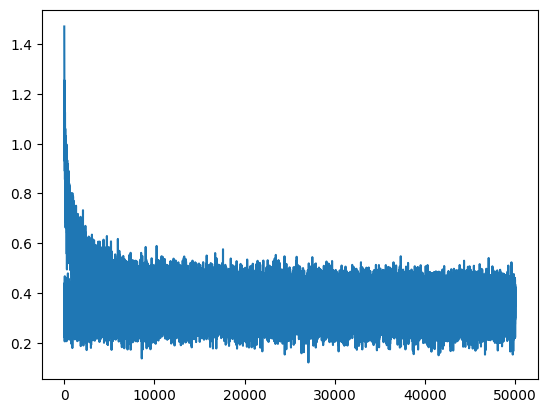

In [203]:
plt.plot(stepi, lossi)

In [205]:
# dev error
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss = -prob[torch.arange(225068), Y].log().mean()
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2036, grad_fn=<NllLossBackward0>)

In [206]:
# check training error
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss = -prob[torch.arange(225068), Y].log().mean()
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1748, grad_fn=<NllLossBackward0>)

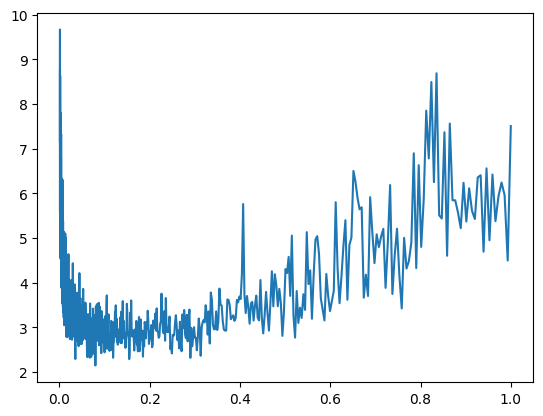

In [140]:
# look at effect on loss of learning rate
plt.plot(lri, lossi)

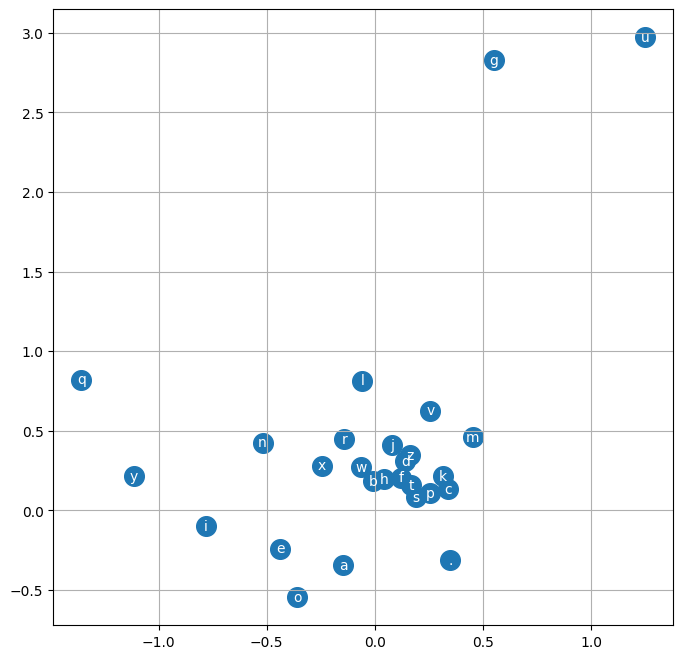

In [186]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [207]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)ß
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amirilli.
kimleigta.
caslandene.
mahurefaperric.
kaqui.
nellari.
chaiiv.
kaleigh.
ham.
pory.
quinn.
sulin.
alian.
quin.
elo.
dearisi.
jaceenissabee.
deciia.
gilee.
